# Antispoofing

In this homework, you will develop a countermeasure against deepfakes and then try to explain it using various XAI techniques.

More specifically, you will implement and train a Countermeasure (CM) system on the Logical Access partition of the [ASVSpoof 2019 Dataset](https://datashare.ed.ac.uk/handle/10283/3336) ([Kaggle Link](https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset)). You may find the [ASVspoof 2019 evaluation plan](https://www.asvspoof.org/asvspoof2019/asvspoof2019_evaluation_plan.pdf) useful.

For the CM, we choose [LightCNN (LCCN)](https://arxiv.org/abs/1511.02683) that once achieved the top place in the competition. We will follow the Speech Technology Center (STC) [paper](https://arxiv.org/abs/1904.05576).

**Hints**:

1. Use STFT (FFT in the paper) as front-end.

2. The dropout layer is put before the last batch norm.

In [ ]:
import os
import tarfile
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from scipy.signal import stft
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import torch.nn as nn
import torch.nn.functional as F

from __future__ import annotations
from dataclasses import dataclass, asdict
from typing import Dict, Optional, Tuple
import torchaudio

import hashlib
import json
import urllib.request
import zipfile
from pathlib import Path
from typing import Any, Dict, List, Optional
from torch.nn.utils.rnn import pad_sequence
import math

## Dataset [0.5 pts]

We want to train a neural network to predict if the input audio is real or fake. To do so, we need a dataset first. In this homework, we will work with [ASVspoof19](https://arxiv.org/pdf/1911.01601.pdf).

Create a `Dataset` class that downloads the dataset, parses its metadata and, given index $i$, returns $i$-th object of the dataset. Do not forget to preprocess audio for LCNN (calculate stft, etc.).

In [ ]:
# !curl -L -o asvpoof-2019-dataset.zip\
#   https://www.kaggle.com/api/v1/datasets/download/awsaf49/asvpoof-2019-dataset

In [ ]:
# !unzip -q ./asvpoof-2019-dataset.zip

In [ ]:
class ASVspoof2019Dataset(Dataset):

    LABEL_MAP = {
        "bonafide": 1,
        "spoof": 0,
    }

    def __init__(
        self,
        root,
        partition="LA",
        split="train",
        sample_rate=16000,
        n_fft=1724,
        hop_length=130,
        win_length=1724,
        num_frames=600,
    ):
        super().__init__()

        self.root = Path(root)
        self.partition = partition
        self.split = split

        self.sample_rate = sample_rate

        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length
        self.num_frames = num_frames

        self.window = torch.blackman_window(win_length)

        self.audio_dir = (
            self.root
            / self.partition
            / f"ASVspoof2019_{partition}_{split}"
            / "flac"
        )

        protocol_name = {
            "train": f"ASVspoof2019.{partition}.cm.train.trn.txt",
            "dev": f"ASVspoof2019.{partition}.cm.dev.trl.txt",
            "eval": f"ASVspoof2019.{partition}.cm.eval.trl.txt",
        }[split]

        self.protocol_path = (
            self.root
            / self.partition
            / f"ASVspoof2019_{partition}_cm_protocols"
            / protocol_name
        )

        self.records = self._load_protocol()

    def _load_protocol(self):

        records = []

        with open(self.protocol_path, "r") as f:

            for line in f:

                parts = line.strip().split()

                speaker_id, utt_id, _, attack, label = parts

                audio_path = self.audio_dir / f"{utt_id}.flac"

                records.append({
                    "path": audio_path,
                    "label": self.LABEL_MAP[label],
                    "utt_id": utt_id,
                    "attack": attack,
                })

        return records

    def _extract_stft(self, waveform):
        """
        Returns:
            [1, F, T]
        """

        spec = torch.stft(
            waveform,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=self.window,
            center=False,
            return_complex=True,
        )
        # magnitude
        spec = spec.abs()
        spec = spec.pow(2)
        spec = torch.log(spec + 1e-10)
        # fix time dimension
        spec = spec[:, :self.num_frames]
        if spec.shape[-1] < self.num_frames:
            pad = self.num_frames - spec.shape[-1]
            spec = F.pad(spec, (0, pad))

        return spec.unsqueeze(0)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):

        item = self.records[idx]
        waveform, sr = torchaudio.load(item["path"])
        # mono
        if waveform.size(0) > 1:
            waveform = waveform.mean(dim=0)

        else:
            waveform = waveform.squeeze(0)
        # resample
        if sr != self.sample_rate:
            waveform = torchaudio.functional.resample(
                waveform,
                sr,
                self.sample_rate,
            )

        waveform = waveform.float()
        # STFT
        spec = self._extract_stft(waveform)

        return {
            "spectrogram": spec,
            "label": item["label"],
        }


def collate_fn(batch):

    specs = torch.stack(
        [item["spectrogram"] for item in batch]
    )

    labels = torch.tensor(
        [item["label"] for item in batch],
        dtype=torch.long,
    )

    return {
        "spectrogram": specs,
        "label": labels,
    }

**Hint**: when working in Kaggle, it is easier and faster to use dataset as kaggle input. We can use it directly or add a symlink to a local dir using `ln -s`.
**Hint**: it might be easier to do this homework in Kaggle, since model training may take some time

Create train/eval dataset and dataloaders:

In [ ]:
train_dataset = ASVspoof2019Dataset(
    root="./dataset/LA",
    partition="LA",
    split="train",
)

dev_dataset = ASVspoof2019Dataset(
    root="./dataset/LA",
    partition="LA",
    split="dev",
)

eval_dataset = ASVspoof2019Dataset(
    root="./dataset/LA",
    partition="LA",
    split="eval",
)

print("Train:", len(train_dataset))
print("Dev:  ", len(dev_dataset))
print("Eval: ", len(eval_dataset))


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
    collate_fn=collate_fn,
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn,
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn,
)


batch = next(iter(train_loader))
print(batch["spectrogram"].shape)
print(batch["label"].shape)

Train: 25380
Dev:   24844
Eval:  71237
torch.Size([8, 1, 863, 600])
torch.Size([8])


Visualize one object, just to check that all is fine:

In [ ]:
train_dataset[0]

{'spectrogram': tensor([[[-19.8008, -20.1059, -20.0923,  ...,   0.0000,   0.0000,   0.0000],
          [-17.1495, -17.8378, -17.8076,  ...,   0.0000,   0.0000,   0.0000],
          [-16.5955, -16.1180, -16.7733,  ...,   0.0000,   0.0000,   0.0000],
          ...,
          [-12.8150, -12.8030, -13.0358,  ...,   0.0000,   0.0000,   0.0000],
          [-13.7575, -13.7578, -13.7879,  ...,   0.0000,   0.0000,   0.0000],
          [-15.7470, -20.3147, -15.6829,  ...,   0.0000,   0.0000,   0.0000]]]),
 'label': 1}

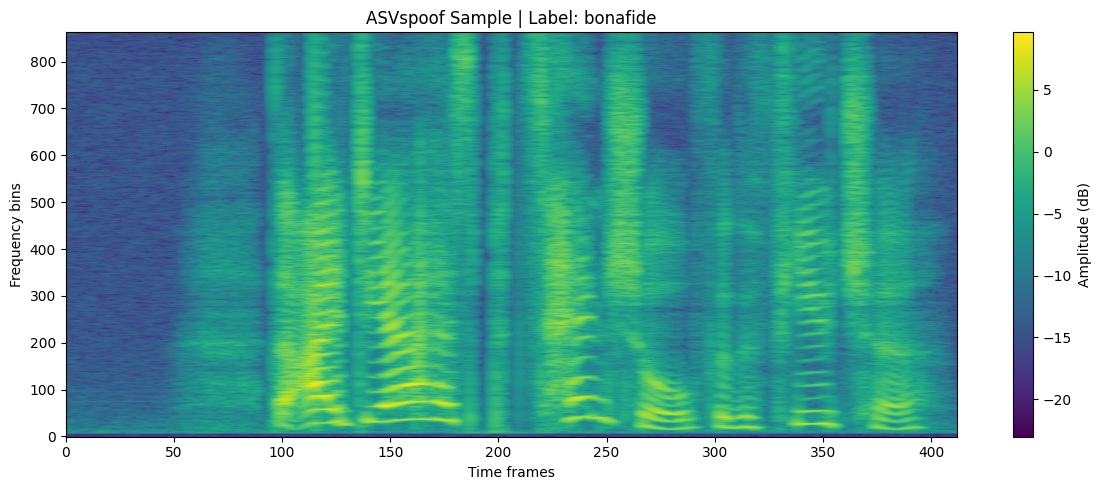

Feature shape: (863, 600)
Label: 1


In [ ]:
sample = train_dataset[0]
spec = sample["spectrogram"]
label = sample["label"]

# Remove channel dimension: [1, F, T] -> [F, T]
spec = spec.squeeze(0).numpy()

plt.figure(figsize=(12, 5))
plt.imshow(
    spec,
    aspect="auto",
    origin="lower",
)
plt.colorbar(label="Amplitude (dB)")
plt.title(f"ASVspoof Sample | Label: {'bonafide' if label == 1 else 'spoof'}")
plt.xlabel("Time frames")
plt.ylabel("Frequency bins")
plt.xlim(0, 412)
plt.tight_layout()
plt.show()

print("Feature shape:", spec.shape)
print("Label:", label)

## Loss function [0.5 pts]

In the lecture, we saw different softmax losses and the motivation behind them for the ASV task. However, they can also be used for any classification task, such as synthesized speech detection. The papers suggest to use A(M)-Softmax or Cross-Entropy. The STC paper argues that A-Softmax is better.

(a) Explain what are the benefits of A-softmax over cross-entropy according to the STC paper?

(b) Analyse the [NII paper](https://arxiv.org/pdf/2103.11326) and explain if complicated Softmax is actually needed to achieve good EER or we can go with Cross Entropy.

**(a) Преимущества A-Softmax перед Cross-Entropy:**
* A-Softmax добавляет штраф за эмбеддинг разных классов, если они получились близкие друг к другу - появляется более сильная (далекая) разделяющая граница между классами; у CE эмбеддиги разных классов могут пересекаться и слабая разделяющая граница между классами; у A-Softmax реальные и спуф эмбеддинги более разделимы в ангулярном пространстве
* A-Softmax имеет больше margin - лучше обучается и обобщает, а не запоминает информацию
* A-Softmax лучше подходит для задач верификации - ранее не детектированные (новые) атаки
* С A-Softmax получется более низкий ERR в задачах анти спуфинга

**(b) complicated Softmax или обычная Cross Entropy?:** \
Не обязательно, так как больший эффект оказывают предобпаботка и выделение фичей, архитектура, тюнинг. Это задача бинарной классификации, так что CE подходит и он проще.

Following tha NII paper, we will continue with Cross Entropy

In [ ]:
from torch import nn

criterion = nn.CrossEntropyLoss()

## Evaluation metric [0.5 pts]

We will use equal error rate as the primary evaluation metric. The code for calculating metrics is provided by the ASVspoof itself. We just need to write a wrapper. Given model logits and labels, calculate EER using the ASVspoof functions.

Your model returns two probas: [spoof_proba, bona_proba]. Be careful with the EER metric and recal how ROC curve is computed to ensure that you do not make a mistake.

In [ ]:
# download asvspoof metric calculation functions
!wget https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py

--2026-05-11 08:58:23--  https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14555 (14K) [text/plain]
Saving to: ‘calculate_eer.py’

calculate_eer.py    100%[===================>]  14.21K  --.-KB/s    in 0.003s  

2026-05-11 08:58:24 (4.69 MB/s) - ‘calculate_eer.py’ saved [14555/14555]



In [ ]:
from calculate_eer import compute_eer

def get_eer(logits, labels):
    # Convert logits -> probabilities
    probs = F.softmax(logits, dim=1)

    # EER expects bonafide scores, not spoof scores.
    # Column 1 = bonafide probability
    bona_scores = probs[:, 1].detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()

    bona_fide_scores = bona_scores[labels == 1]
    spoof_scores = bona_scores[labels == 0]

    eer, threshold = compute_eer(
        bona_fide_scores,
        spoof_scores,
    )

    return eer

## LCNN Implementation [6.0 pts]

Create a `LCNN` class for the model architecture.

In [ ]:
class MaxFeatureMap2D(nn.Module):
    """
    MFM activation for Conv2D outputs.
    Input:
        [B, C, H, W]
    Output:
        [B, C/2, H, W]
    """

    def forward(self, x):
        b, c, h, w = x.shape
        assert c % 2 == 0, "Channels must be even"

        x = x.view(b, c // 2, 2, h, w)
        return x.max(dim=2).values


class MaxFeatureMap1D(nn.Module):
    """
    MFM activation for Linear outputs.

    Input:
        [B, C]
    Output:
        [B, C/2]
    """

    def forward(self, x):
        b, c = x.shape
        assert c % 2 == 0, "Features must be even"

        x = x.view(b, c // 2, 2)
        return x.max(dim=2).values


class LCNN(nn.Module):

    def __init__(
        self,
        num_classes=2,
        dropout_p=0.5,
    ):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(1, 64, kernel_size=5, padding=2),
            MaxFeatureMap2D(),          # 64 -> 32
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=1),
            MaxFeatureMap2D(),          # 64 -> 32

            nn.Conv2d(32, 96, kernel_size=3, padding=1),
            MaxFeatureMap2D(),          # 96 -> 48
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(48, 96, kernel_size=1),
            MaxFeatureMap2D(),          # 96 -> 48

            nn.Conv2d(48, 128, kernel_size=3, padding=1),
            MaxFeatureMap2D(),          # 128 -> 64
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(64, 128, kernel_size=1),
            MaxFeatureMap2D(),          # 128 -> 64

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            MaxFeatureMap2D(),          # 64 -> 32
            nn.MaxPool2d(2, 2),
        )

        self.global_pool = nn.AdaptiveAvgPool2d((8, 8))
        self.fc1 = nn.Linear(32 * 8 * 8, 160)
        self.mfm_fc = MaxFeatureMap1D()     # 160 -> 80
        self.dropout = nn.Dropout(dropout_p)
        self.bn = nn.BatchNorm1d(80)
        self.fc2 = nn.Linear(80, num_classes)
        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        Input:
            [B, 1, F, T]
        """
        # CNN backbone
        x = self.features(x)
        x = self.global_pool(x)
        x = x.flatten(1)
        x = self.fc1(x)
        x = self.mfm_fc(x)
        x = self.dropout(x)
        x = self.bn(x)
        logits = self.fc2(x)
        return logits

In [ ]:
# double-check that it runs (do eval mode)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LCNN().to(device)

model.eval()

# [batch, channel, freq, time]
x = torch.randn(4, 1, 257, 400).to(device)

with torch.no_grad():
    logits = model(x)

print("Input shape :", x.shape)
print("Output shape:", logits.shape)

Input shape : torch.Size([4, 1, 257, 400])
Output shape: torch.Size([4, 2])


Write the train loop. Since it may take some time, we advise you to save your checkpoints after each epoch to load it back if needed.

Plot EER vs epoch and loss vs epoch curves

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device):

    model.train()
    total_loss = 0.0

    for b in dataloader:
        x = b['spectrogram'].to(device)
        y = b['label'].to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    return total_loss / len(dataloader)

In [ ]:
def evaluate(model, dataloader, criterion, device):

    model.eval()
    total_loss = 0.0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for b in dataloader:
            x = b['spectrogram'].to(device)
            y = b['label'].to(device)

            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item()

            all_logits.append(logits.cpu())
            all_labels.append(y.cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    eer = get_eer(all_logits, all_labels)

    return total_loss / len(dataloader), eer

In [ ]:
def train(
    model,
    train_dataloader,
    eval_dataloader,
    criterion,
    optimizer,
    scheduler,
    device,
    n_epochs
):

    train_losses = []
    val_losses = []
    val_eers = []

    for epoch in range(n_epochs):

        print(f"\nEpoch {epoch+1}/{n_epochs}")
        train_loss = train_one_epoch(
            model,
            train_dataloader,
            criterion,
            optimizer,
            scheduler,
            device
        )
        val_loss, val_eer = evaluate(
            model,
            eval_dataloader,
            criterion,
            device
        )
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_eers.append(val_eer)

        print(f"Train loss: {train_loss:.4f}")
        print(f"Val loss:   {val_loss:.4f}")
        print(f"Val EER:    {val_eer:.4f}")
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
            },
            f"lcnn_epoch_{epoch}.pt"
        )

    plt.figure()
    plt.plot(train_losses, label="train loss")
    plt.plot(val_losses, label="val loss")
    plt.legend()
    plt.title("Loss vs Epoch")
    plt.show()

    plt.figure()
    plt.plot(val_eers, label="val EER")
    plt.legend()
    plt.title("EER vs Epoch")
    plt.show()

    return train_losses, val_losses, val_eers

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# take optimizer and scheduler from the NII paper
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.999),
    eps=1e-8
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)
n_epochs = 7

In [ ]:
train(model, train_loader, eval_loader,
      criterion, optimizer, scheduler, device, n_epochs)


Epoch 1/7
Train loss: 0.3851
Val loss:   0.2339
Val EER:    0.1840

Epoch 2/7
Train loss: 0.2004
Val loss:   0.3819
Val EER:    0.0885

Epoch 3/7
Train loss: 0.0430
Val loss:   0.5994
Val EER:    0.0617

Epoch 4/7


KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load("lcnn_epoch_2.pt", map_location=device)
model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])
scheduler.load_state_dict(checkpoint["scheduler_state"])
start_epoch = checkpoint["epoch"]

print("Loaded checkpoint from epoch:", start_epoch)

Loaded checkpoint from epoch: 2


Остановила раньше так как ошибка достигла 6% на валидации, а каждая эпоха считается по часу

The task is consired solved if you achieve at least $9\%$ EER. It is much higher than the model can achieve but we do not want you to wait 12+ hours for the model to converge.

## XAI [See points below]

Let's analyse the model we have created. We won't be able to understand the differences easily without having some reference. So, we will use the novel idea from the recent [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425).

We will use a [vocoded dataset](https://arxiv.org/abs/2210.10570) of parallel samples: real and fake audio have the same speaker saying the same content at the same time. The ground-truth explanation will be obtained by calculating difference between real and fake spectrograms.

In [ ]:
!wget "https://zenodo.org/records/7314976/files/project09-voc.v4.tar?download=1" -O project09-voc.v4.tar
!tar -xvf project09-voc.v4.tar

--2026-05-11 11:29:47--  https://zenodo.org/records/7314976/files/project09-voc.v4.tar?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.52.235, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2284677120 (2.1G) [application/octet-stream]
Saving to: ‘project09-voc.v4.tar’

project09-voc.v4.ta 100%[===================>]   2.13G  14.7MB/s    in 2m 33s  

2026-05-11 11:32:21 (14.2 MB/s) - ‘project09-voc.v4.tar’ saved [2284677120/2284677120]

voc.v4/
voc.v4/LICENSE
voc.v4/wav/
voc.v4/wav/waveglow_LA_D_1183785.wav
voc.v4/wav/waveglow_LA_D_1214950.wav
voc.v4/wav/waveglow_LA_D_2733428.wav
voc.v4/wav/waveglow_LA_D_3215740.wav
voc.v4/wav/waveglow_LA_D_8138324.wav
voc.v4/wav/waveglow_LA_D_8274833.wav
voc.v4/wav/waveglow_LA_D_9209591.wav
voc.v4/wav/waveglow_LA_T_5100132.wav
voc.v4/wav/waveglow_LA_T_6423802.wav
voc.v4/wav/waveglow_LA_T_7226623.wav
voc.v4/wav/waveglow_LA_T_91105

Note that real audio is taken from ASVspoof. So let's take a real example from the asvspoof dataset. Using its filename, find the corresponding `hifi-gan` and `waveglow` vocoded versions in the vocv4 and load them too

In reality, we are interested in the explanations for the unseen data. But for this homework, let's consider the train set. This will allow us to see if the model learns the futures we expect it to learn (assuming the XAI tool is trustworthy) (Though spoof part of vocv4 is not exactly the same as the one in asvspoof, so we mostly eliminate the issues related to changing speakers, not algorithms)

In [ ]:
# for consistency with solutions choose the index that corresponds to LA_T_4179989 (bona fide)
target_id = "LA_T_4179989"
idx = next(
    i for i, r in enumerate(train_dataset.records)
    if r["utt_id"] == target_id
)

print(idx)
print(train_dataset.records[idx])

50
{'path': PosixPath('dataset/LA/LA/ASVspoof2019_LA_train/flac/LA_T_4179989.flac'), 'label': 1, 'utt_id': 'LA_T_4179989', 'attack': '-'}


In [ ]:
# get LCNN-prepared spectrogram for the paired real and fake example from the dataset
# paired: the same filename, but one is bona fide another is created via vocoder
sample = train_dataset[idx]
real_path = train_dataset.records[idx]['path']
real_audio, sr = librosa.load(real_path, sr=train_dataset.sample_rate)

voc_root = Path("voc.v4/wav")
hifigan_path = voc_root / f"hifigan_{target_id}.wav"
waveglow_path = voc_root / f"waveglow_{target_id}.wav"

hifigan_audio, _ = librosa.load(hifigan_path, sr=sr)
waveglow_audio, _ = librosa.load(waveglow_path, sr=sr)

In [ ]:
print("REAL (bona fide)")
display(Audio(real_audio, rate=sr))
print("HiFi-GAN (vocoded fake)")
display(Audio(hifigan_audio, rate=sr))
print("WaveGlow (vocoded fake)")
display(Audio(waveglow_audio, rate=sr))

REAL (bona fide)


HiFi-GAN (vocoded fake)


WaveGlow (vocoded fake)


In [ ]:
# fake audio may be slightly longer due to padding, remove some part from the end to make the length equal
min_len = min(
    len(real_audio),
    len(hifigan_audio),
    len(waveglow_audio),
)
real_audio = real_audio[:min_len]
hifigan_audio = hifigan_audio[:min_len]
waveglow_audio = waveglow_audio[:min_len]

In [ ]:
import torch
import torch.nn.functional as F

def extract_lcnn_feature_from_wav(wav, dataset):
    """
    wav: numpy or torch [T]
    returns: [1, 1, F, T]
    """

    if not torch.is_tensor(wav):
        wav = torch.tensor(wav)

    wav = wav.float()

    # ensure shape [T]
    if wav.dim() > 1:
        wav = wav.squeeze()

    window = torch.blackman_window(dataset.win_length).to(wav.device)

    spec = torch.stft(
        wav,
        n_fft=dataset.n_fft,
        hop_length=dataset.hop_length,
        win_length=dataset.win_length,
        window=window,
        center=False,
        return_complex=True,
    )

    # magnitude -> power -> log
    spec = spec.abs()
    spec = spec.pow(2)
    spec = torch.log(spec + 1e-10)
    # truncate / pad time axis
    spec = spec[:, :dataset.num_frames]

    if spec.shape[-1] < dataset.num_frames:
        pad = dataset.num_frames - spec.shape[-1]
        spec = F.pad(spec, (0, pad))

    # [F, T] -> [1, 1, F, T]
    spec = spec.unsqueeze(0).unsqueeze(0)

    return spec.float()


real_feat = extract_lcnn_feature_from_wav(real_audio, train_dataset)
hifi_feat = extract_lcnn_feature_from_wav(hifigan_audio, train_dataset)
waveglow_feat = extract_lcnn_feature_from_wav(waveglow_audio, train_dataset)

real_tensor = torch.tensor(real_feat).to(device)
hifi_tensor = torch.tensor(hifi_feat).to(device)
wg_tensor = torch.tensor(waveglow_feat).to(device)

/var/folders/rl/v0rh39_d2kjg2py2z0vd10n00000gn/T/ipykernel_34940/958357379.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  real_tensor = torch.tensor(real_feat).to(device)
/var/folders/rl/v0rh39_d2kjg2py2z0vd10n00000gn/T/ipykernel_34940/958357379.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hifi_tensor = torch.tensor(hifi_feat).to(device)
/var/folders/rl/v0rh39_d2kjg2py2z0vd10n00000gn/T/ipykernel_34940/958357379.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wg_tensor = torch.tensor(waveglow_feat).to(device)


Run your model on these clips. See if the model prediction is correct. Use this understanding for the following analysis

In [ ]:
model.eval()

with torch.no_grad():

    real_logits = model(real_tensor)
    hifi_logits = model(hifi_tensor)
    wg_logits = model(wg_tensor)

    real_pred = torch.softmax(real_logits, dim=1)
    hifi_pred = torch.softmax(hifi_logits, dim=1)
    wg_pred = torch.softmax(wg_logits, dim=1)

print("REAL:", real_pred.cpu().numpy())
print("HIFI-GAN:", hifi_pred.cpu().numpy())
print("WAVEGLOW:", wg_pred.cpu().numpy())

REAL: [[0.00478857 0.9952114 ]]
HIFI-GAN: [[0.07593855 0.9240615 ]]
WAVEGLOW: [[0.9951473  0.00485275]]


Модель на HIFI-GAN склоняется сильнее, что это реальная (нужен трешхолд > 93)

### Manual explanation [0.5 pts]

Compare the two spectrograms (real and fake). What differences do you see? (**Hint**: they exist, if you do not see -- look carefully).

In [ ]:
def plot_comparison(real_feat, fake_feat, title="Comparison"):
    diff = real_feat - fake_feat

    plt.figure(figsize=(15, 4))

    # Real
    plt.subplot(1, 3, 1)
    plt.imshow(real_feat, aspect="auto", origin="lower")
    plt.title("Real speech")
    plt.colorbar()
    plt.xlim(0, 340)

    # Fake
    plt.subplot(1, 3, 2)
    plt.imshow(fake_feat, aspect="auto", origin="lower")
    plt.title("Vocoded speech")
    plt.colorbar()
    plt.xlim(0, 340)

    # Difference
    plt.subplot(1, 3, 3)
    plt.imshow(diff, aspect="auto", origin="lower", cmap="seismic")
    plt.title("Difference (Real - Fake)")
    plt.colorbar()
    plt.xlim(0, 340)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    return diff

In [ ]:
real_spec = real_feat.squeeze().cpu().numpy()
hifigan_spec = hifi_feat.squeeze().cpu().numpy()
waveglow_spec = waveglow_feat.squeeze().cpu().numpy()

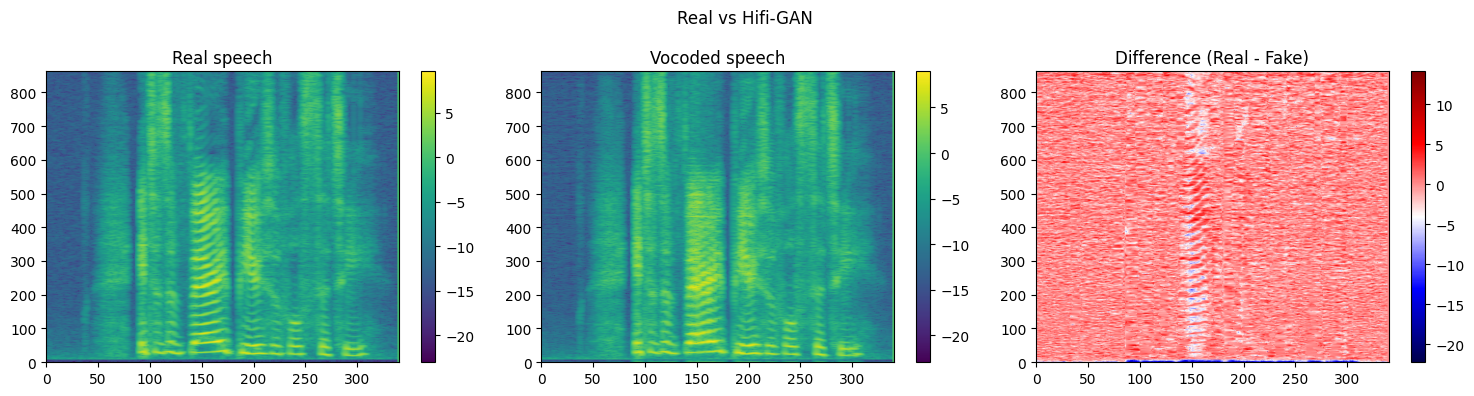

In [ ]:
diff_hifi = plot_comparison(
    real_spec,
    hifigan_spec,
    title="Real vs Hifi-GAN"
)

В реальной спектрограмме на 150 есть более сильная и четкая магнитуда

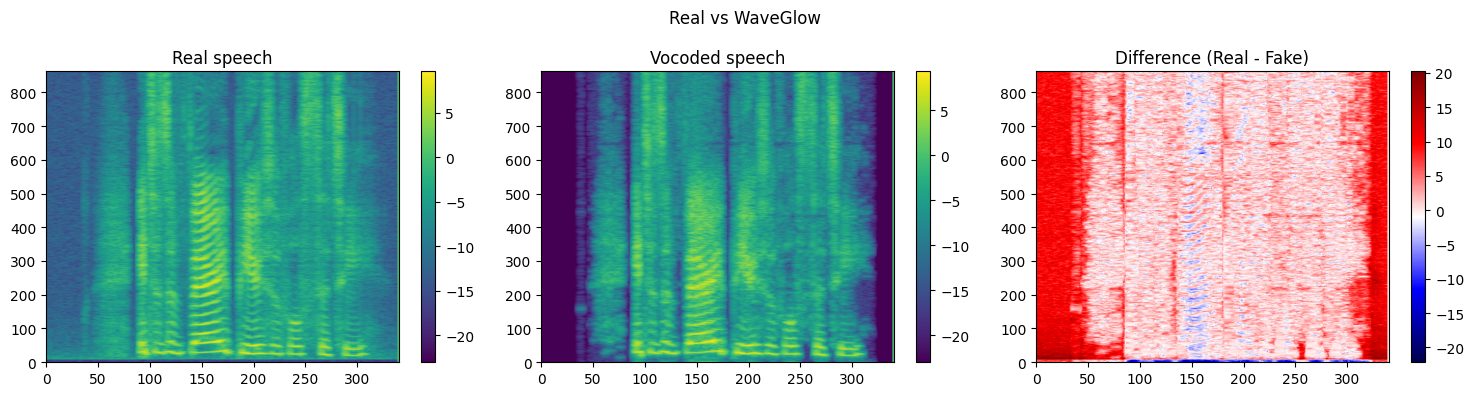

In [ ]:
diff_wg = plot_comparison(
    real_spec,
    waveglow_spec,
    title="Real vs WaveGlow"
)

В сгенерированной речи по краям очень слабая магнитуда в отличии от реальной и на 150 также, как и в предыдущей в реальной спектрограмме есть более сильная и четкая магнитуда

In [ ]:
print("Hifi-GAN L1 diff:", np.mean(np.abs(diff_hifi)))
print("WaveGlow L1 diff:", np.mean(np.abs(diff_wg)))

Hifi-GAN L1 diff: 0.823104
WaveGlow L1 diff: 2.0815704


У WaveGlow намного более сильное отличие от реальной спектрограммы, чем у Hifi-GAN, которая почти такая же

### Automatic explanation. [0.5 pts]

Calculate Eq. 2 from the [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425) to automatically highlight the differences between two objects

In [ ]:
def eq2_mask(real, fake, eps=1e-8):
    diff = np.abs(real - fake)
    norm = np.abs(real) + np.abs(fake) + eps
    mask = diff / norm
    # normalize for visualization
    mask = (mask - mask.min()) / (mask.max() - mask.min() + eps)
    return mask

Plot the mask on top of the fake spectrogram and compare three plots: real, fake, fake+mask on top. Do it for both vocoders. Compare

In [ ]:
def plot_real_fake_mask(real, fake, mask, title):

    plt.figure(figsize=(15,4))

    # REAL
    plt.subplot(1,3,1)
    plt.imshow(real, origin="lower", aspect="auto")
    plt.title("Real")
    plt.colorbar()
    plt.xlim(0, 340)

    # FAKE
    plt.subplot(1,3,2)
    plt.imshow(fake, origin="lower", aspect="auto")
    plt.title("Fake")
    plt.colorbar()
    plt.xlim(0, 340)

    # FAKE + MASK overlay
    plt.subplot(1,3,3)
    plt.imshow(fake, origin="lower", aspect="auto")
    plt.imshow(mask, origin="lower", aspect="auto")
    plt.title("Fake + Eq.2 Mask")
    plt.colorbar()
    plt.xlim(0, 340)

    plt.suptitle(title)
    plt.show()

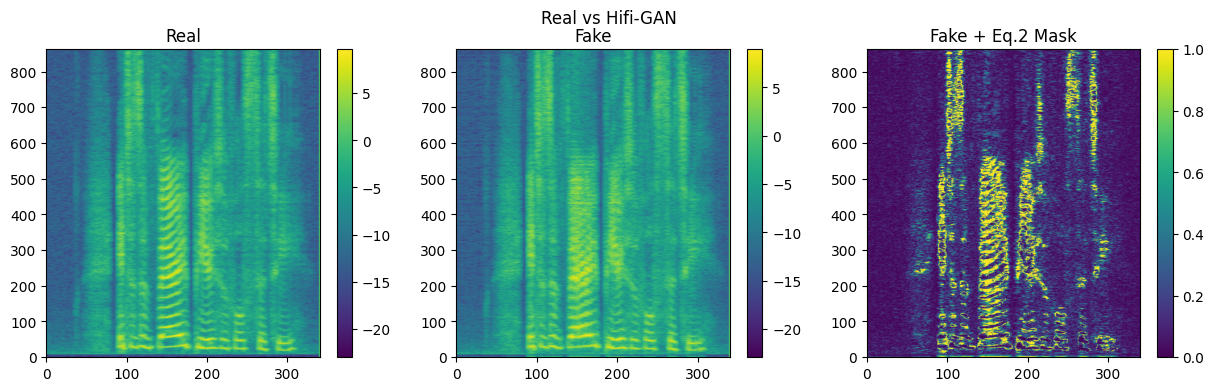

In [ ]:
mask_hifi = eq2_mask(real_spec, hifigan_spec)

plot_real_fake_mask(
    real_spec,
    hifigan_spec,
    mask_hifi,
    "Real vs Hifi-GAN"
)

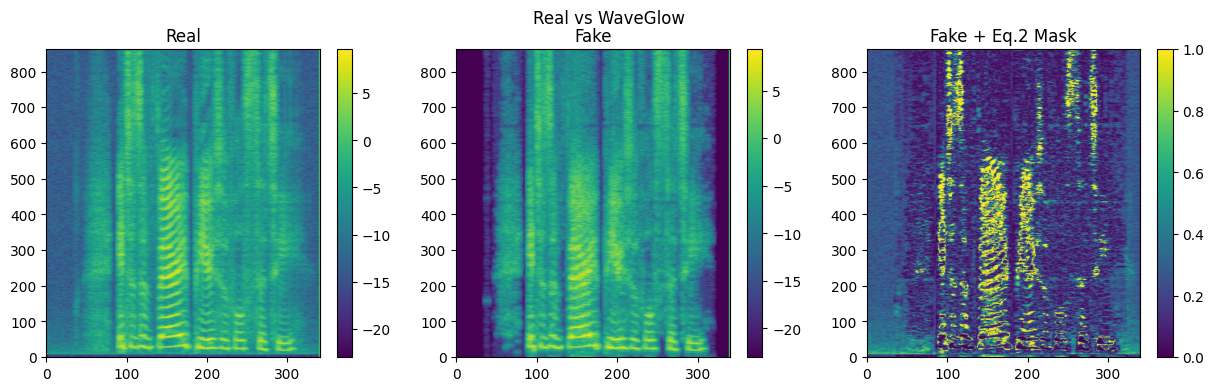

In [ ]:
mask_wg = eq2_mask(real_spec, waveglow_spec)

plot_real_fake_mask(
    real_spec,
    waveglow_spec,
    mask_wg,
    "Real vs WaveGlow"
)

Здесь намного сильнее выделены зоны от 100 до 300 с явными различиями, в отличии от рисунка ранее. \
Однако тут не так сильно заметна слабая магнитуда по краям у WaveGlow. \
В целом различия у Hifi-GAN и WaveGlow здесь позожи, но у Hifi-GAN они немного ярче

### Grad-CAM [0.5 pts]

Using [pytorch-grad-cam lib](https://github.com/jacobgil/pytorch-grad-cam), implement [Grad-CAM](https://arxiv.org/abs/1610.02391) for your LCNN model. Choose the layer you like

In [ ]:
# grad-cam and captum may have conflicting numpy dependencies. Just install grad-cam first, then captum and it will work

In [ ]:
!pip install grad-cam

  Using cached grad_cam-1.5.5-py3-none-any.whl
  Using cached torchvision-0.26.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached ttach-0.0.3-py3-none-any.whl.metadata (5.2 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
Using cached torchvision-0.26.0-cp310-cp310-macosx_11_0_arm64.whl (1.9 MB)
Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached ttach-0.0.3-py3-none-any.whl (9.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [grad-cam]3/5 [torchvision]n]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


def compute_gradcam(model, input_tensor, target_class, target_layer):
    """
    Args:
        model: LCNN model
        input_tensor: (1, C, F, T) or similar
        target_class: int (e.g., 0 or 1)
        target_layer: selected conv layer
    """

    model.eval()
    cam = GradCAM(
        model=model,
        target_layers=[target_layer]
    )
    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]  # remove batch dim

    return grayscale_cam

objc[34940]: Class AVFFrameReceiver is implemented in both /opt/homebrew/Cellar/ffmpeg/8.0.1_4/lib/libavdevice.62.1.100.dylib (0x114030328) and /Users/yuliya/projects/dls_sound/venv10/lib/python3.10/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x135aac3a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[34940]: Class AVFAudioReceiver is implemented in both /opt/homebrew/Cellar/ffmpeg/8.0.1_4/lib/libavdevice.62.1.100.dylib (0x114030378) and /Users/yuliya/projects/dls_sound/venv10/lib/python3.10/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x135aac3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


In [ ]:
def visualize_cam(spectrogram, cam):
    """
    spectrogram: (F, T) numpy
    cam: (F, T) numpy from Grad-CAM
    """

    spectrogram = spectrogram - spectrogram.min()
    spectrogram = spectrogram / (spectrogram.max() + 1e-8)

    visualization = show_cam_on_image(
        spectrogram[..., None],  # fake RGB
        cam,
        use_rgb=False
    )

    plt.figure(figsize=(8, 4))
    plt.imshow(visualization, aspect='auto', origin='lower')
    plt.title("Grad-CAM LCNN")
    plt.axis("off")
    plt.xlim(0, 340)
    plt.show()


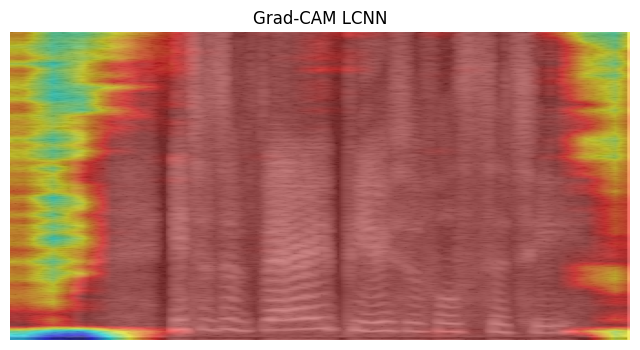

In [ ]:
target_layer = model.features[-1]  # best default choice

hifi_input_tensor = hifi_tensor.to(device)
hifi_cam = compute_gradcam(
    model=model,
    input_tensor=hifi_input_tensor,
    target_class=0, # какие части заставляют модель думать, что это fake
    target_layer=target_layer
)
hifi_spec = hifi_input_tensor.squeeze().detach().cpu().numpy()
visualize_cam(hifi_spec, hifi_cam)

Выдают, что hifigan фейк:
* Сильная активация на границах особенно на высоких частотах, вертикальные полосы
* В начале очень сильная активация на низкой частоте

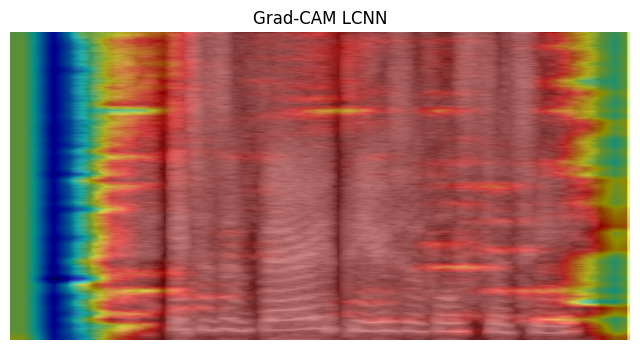

In [ ]:
wg_input_tensor = wg_tensor.to(device)
wg_cam = compute_gradcam(
    model=model,
    input_tensor=wg_input_tensor,
    target_class=0,
    target_layer=target_layer
)
wg_spec = wg_input_tensor.squeeze().detach().cpu().numpy()
visualize_cam(wg_spec, wg_cam)

Выдают, что waveglow фейк:

* Очень сильная активация вначале, вертикальные полосы
* Небольшой кусок в центре

В целом границы (особенно начало) выдают, что аудио фейк

### Comparison [1.0 pts]

Compare your Grad-CAM attributions with another gradient-based method: InputXGradient. Compute it using [Captum](https://captum.ai/).

In [ ]:
!pip install captum

  Using cached captum-0.9.0-py3-none-any.whl.metadata (24 kB)
Using cached captum-0.9.0-py3-none-any.whl (455 kB)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from captum.attr import InputXGradient

model.eval()

x = hifi_tensor  # or wg_tensor
x.requires_grad = True
ig = InputXGradient(model)

attr = ig.attribute(x, target=1)

# remove batch/channel dims -> [F, T]
attr = attr.squeeze().detach().cpu().numpy()
attr = np.abs(attr)
hifi_attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

In [ ]:
model.eval()

x = wg_tensor
x.requires_grad = True
ig = InputXGradient(model)

# target class = spoof (1)
attr = ig.attribute(x, target=1)

# remove batch/channel dims -> [F, T]
attr = attr.squeeze().detach().cpu().numpy()
attr = np.abs(attr)
wg_attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

In [ ]:
def plot_xai_comparison(spec, gradcam, ixg, title):

    plt.figure(figsize=(15,4))

    # Spectrogram
    plt.subplot(1,3,1)
    plt.imshow(spec, origin="lower", aspect="auto")
    plt.title("Fake spectrogram")
    plt.colorbar()
    plt.xlim(0, 340)

    # Grad-CAM
    plt.subplot(1,3,2)
    plt.imshow(spec, origin="lower", aspect="auto")
    plt.imshow(gradcam, origin="lower", aspect="auto")
    plt.title("Grad-CAM")
    plt.colorbar()
    plt.xlim(0, 280)

    # Input × Gradient
    plt.subplot(1,3,3)
    plt.imshow(spec, origin="lower", aspect="auto")
    plt.imshow(ixg, aspect="auto", origin="lower", cmap='hot')
    plt.title("Input × Gradient")
    plt.colorbar()
    plt.xlim(0, 280)

    plt.suptitle(title)
    plt.show()

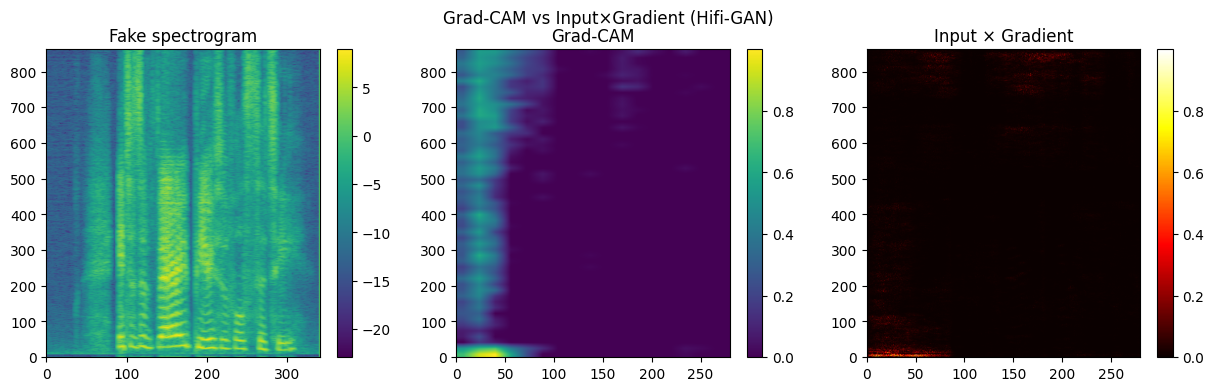

In [ ]:
plot_xai_comparison(
    hifi_tensor.squeeze().detach().cpu().numpy(),
    hifi_cam,
    hifi_attr,
    "Grad-CAM vs Input×Gradient (Hifi-GAN)"
)

Начало аудио (особенно на низкой частоте) выдает, что это фейк, но это не так сильно заметно на Input×Gradient

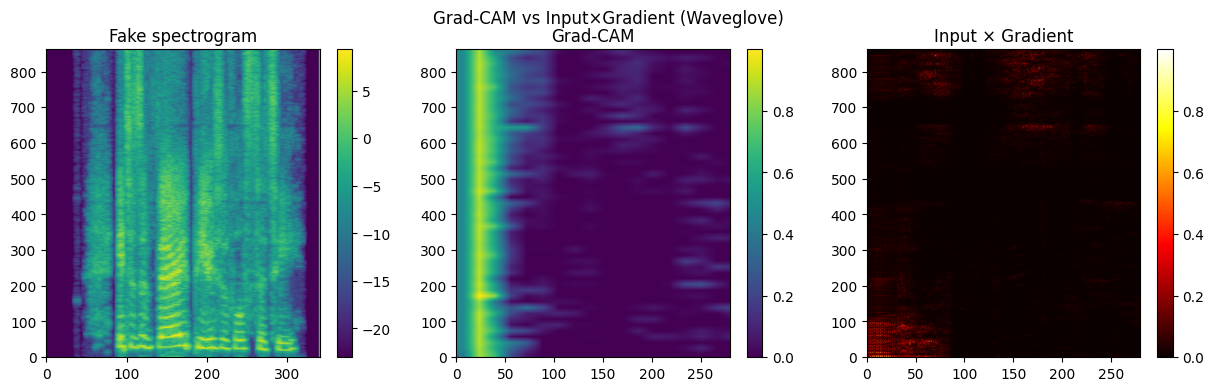

In [ ]:
plot_xai_comparison(
    wg_tensor.squeeze().detach().cpu().numpy(),
    wg_cam,
    wg_attr,
    "Grad-CAM vs Input×Gradient (Waveglove)"
)

Начало аудио (особенно на низкой частоте) выдает, что это фейк, а также середина на высоких частотах

Для WaveGlow сильнее заметно, что это фейк, чем у hifigan в подходе Input×Gradient

Do three plots: mask vs grad-cam vs inputXgradient. Compare them. Does any of the XAI methods align with the mask?

In [ ]:
import cv2
import numpy as np

hifi_grayscale_cam = cv2.resize(
    hifi_cam,
    (hifigan_spec.shape[1], hifigan_spec.shape[0])
)

wg_grayscale_cam = cv2.resize(
    wg_cam,
    (waveglow_spec.shape[1], waveglow_spec.shape[0])
)

In [ ]:
import matplotlib.pyplot as plt

def plot_three_explanations(spec, mask, cam, ixg, title):

    plt.figure(figsize=(18, 4))

    # 1. Mask (Eq. 2)
    plt.subplot(1, 3, 1)
    plt.imshow(spec, origin="lower", aspect="auto")
    plt.imshow(mask, origin="lower", aspect="auto") # cmap="hot", alpha=0.5,
    plt.title("Eq.(2) Mask (Real vs Fake)")
    plt.colorbar()
    plt.xlim(0, 340)

    # 2. Grad-CAM
    plt.subplot(1, 3, 2)
    plt.imshow(spec, origin="lower", aspect="auto")
    plt.imshow(cam, origin="lower", aspect="auto")
    plt.title("Grad-CAM")
    plt.colorbar()
    plt.xlim(0, 340)

    # 3. Input × Gradient
    plt.subplot(1, 3, 3)
    plt.imshow(spec, origin="lower", aspect="auto")
    plt.imshow(ixg, origin="lower",aspect="auto", cmap="viridis") # cmap="viridis", alpha=0.5,
    plt.title("Input × Gradient")
    plt.colorbar()
    plt.xlim(0, 340)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

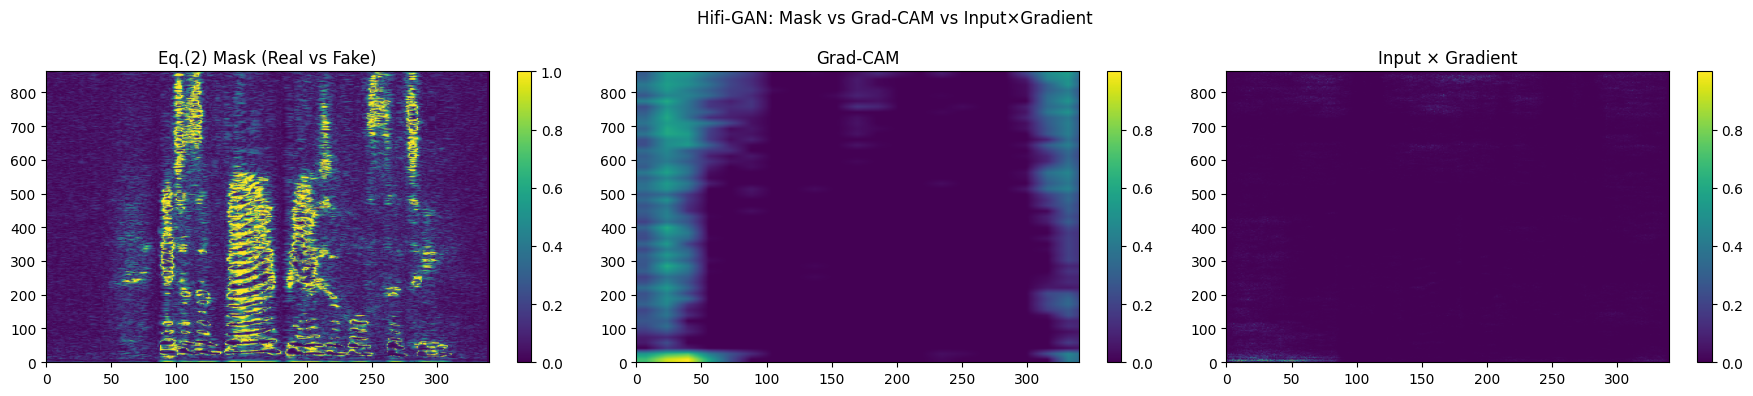

In [ ]:
plot_three_explanations(
    hifigan_spec,
    mask_hifi,
    hifi_grayscale_cam,
    hifi_attr,
    "Hifi-GAN: Mask vs Grad-CAM vs Input×Gradient"
)

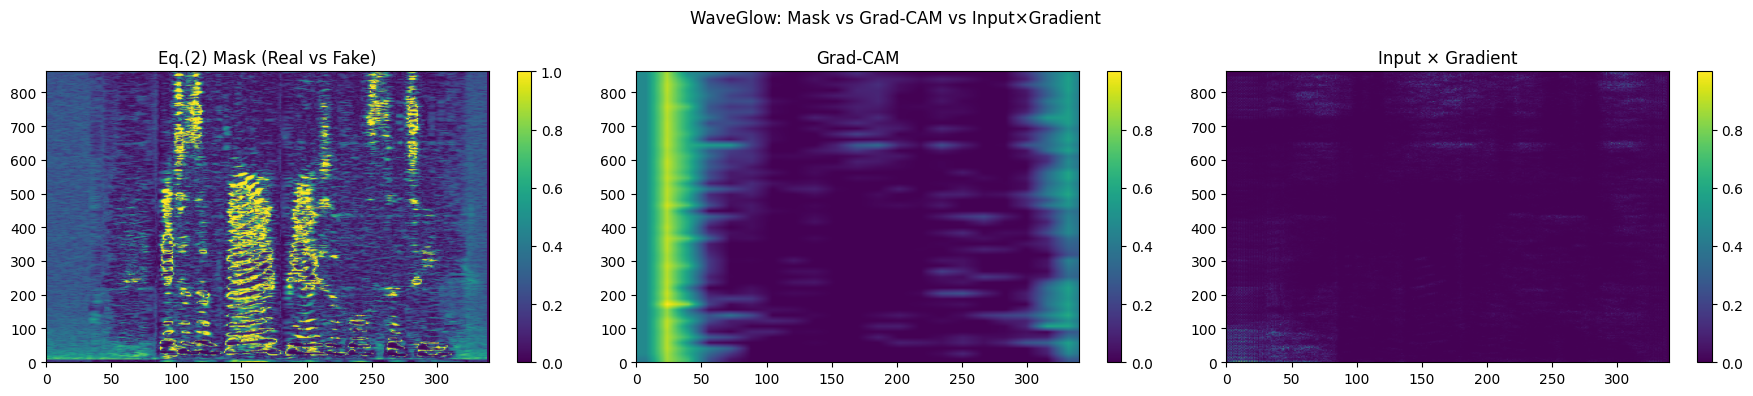

In [ ]:
plot_three_explanations(
    waveglow_spec,
    mask_wg,
    wg_grayscale_cam,
    wg_attr,
    "WaveGlow: Mask vs Grad-CAM vs Input×Gradient"
)

С маской не совпадает ни один метод, так как оба метода активируются на начало, а в маске больше всего заметно на 150й. \
По методу grad cam легче увидеть, что аудио фейк, чем по IG (который слабо активируется)

Due to skewed distribution for some XAI tools, you may want to look at top-5% points, similarly to the ground-truth mask. Binarize attributions using their $95\%$ quantile and plot again:

In [ ]:
def binarize_top5(x):
    """
    Keep only top 5% most important values.
    """
    thr = np.quantile(x, 0.95)
    return (x >= thr).astype(np.float32)

In [ ]:
hifi_mask_bin = binarize_top5(mask_hifi)
hifi_cam_bin = binarize_top5(hifi_grayscale_cam)
hifi_ixg_bin = binarize_top5(hifi_attr)

wg_mask_bin = binarize_top5(mask_wg)
wg_cam_bin = binarize_top5(wg_grayscale_cam)
wg_ixg_bin = binarize_top5(wg_attr)

In [ ]:
def plot_binary_comparison(spec, mask, cam, ixg, title):

    plt.figure(figsize=(18, 4))

    # Eq(2) mask
    plt.subplot(1, 3, 1)
    plt.imshow(spec, origin="lower", aspect="auto")
    plt.imshow(mask, aspect="auto", origin="lower")
    plt.title("Eq.(2) Top 5% Mask")
    plt.xlim(0, 340)

    # Grad-CAM
    plt.subplot(1, 3, 2)
    plt.imshow(spec, origin="lower", aspect="auto")
    plt.imshow(cam, aspect="auto", origin="lower")
    plt.title("Grad-CAM Top 5%")
    plt.xlim(0, 340)

    # Input × Gradient
    plt.subplot(1, 3, 3)
    plt.imshow(spec, origin="lower", aspect="auto")
    plt.imshow(ixg, aspect="auto", origin="lower")
    plt.title("Input×Gradient Top 5%")
    plt.xlim(0, 340)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

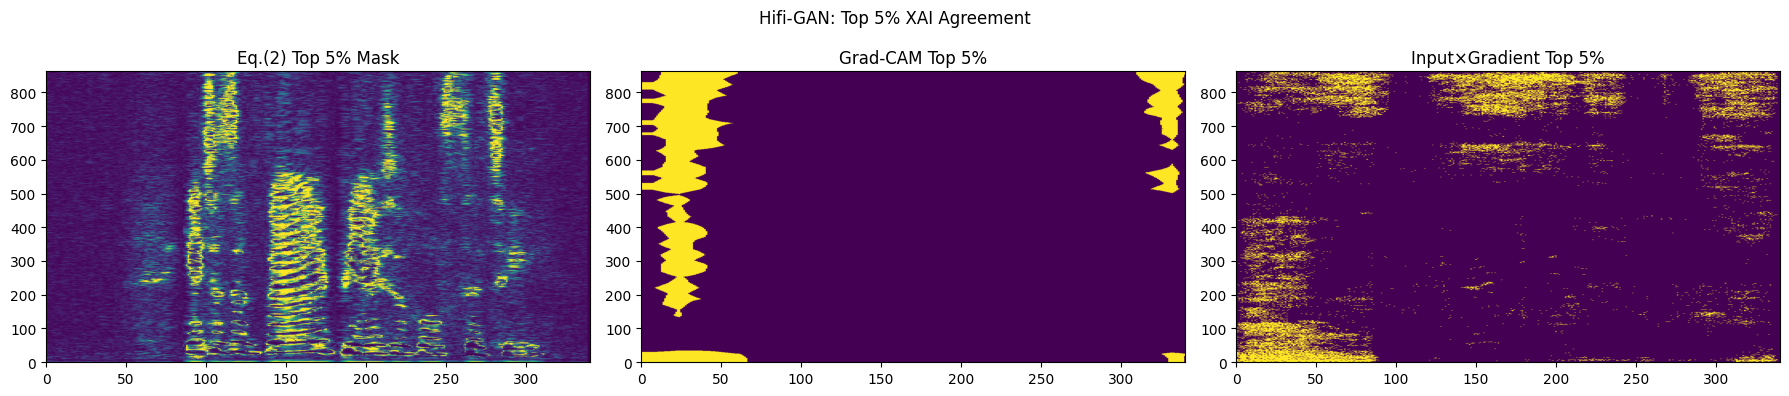

In [ ]:
plot_binary_comparison(
    hifi_spec,
    mask_hifi,
    hifi_cam_bin,
    hifi_ixg_bin,
    "Hifi-GAN: Top 5% XAI Agreement"
)

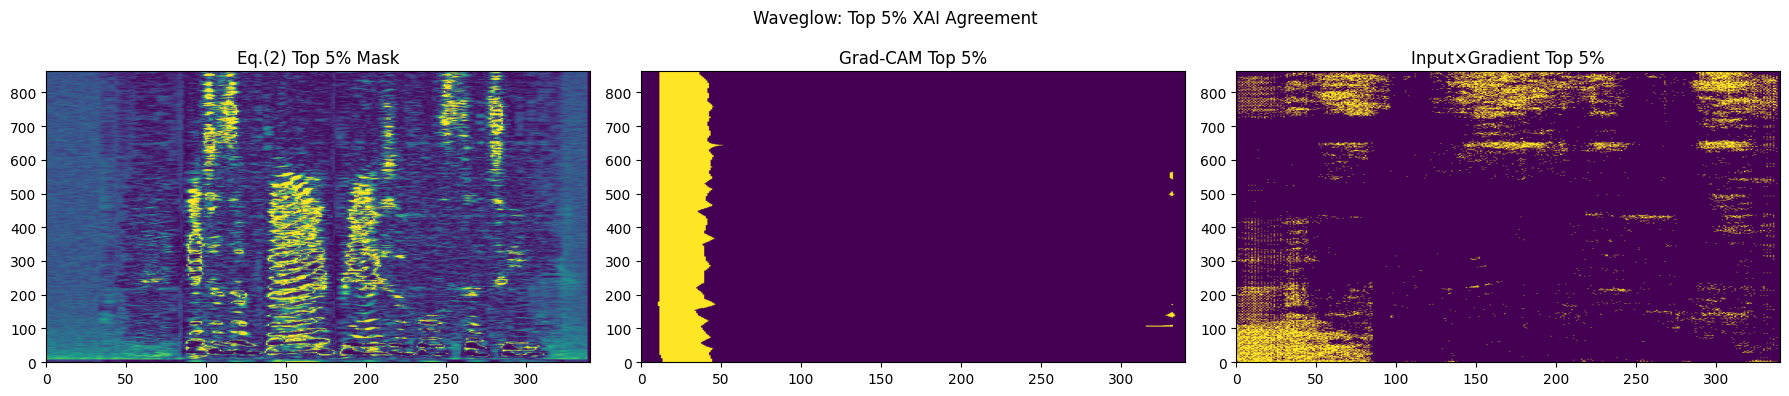

In [ ]:
plot_binary_comparison(
    waveglow_spec,
    mask_wg,
    wg_cam_bin,
    wg_ixg_bin,
    "Waveglow: Top 5% XAI Agreement"
)

* С маской по прежнему не совпадает ни один метод, так как оба метода активируются на начало, а в маске больше всего заметно на 150й.
* По методу grad cam легче увидеть, что аудио фейк именно по началу
* По методу IG также подсвечена середина и конец - найдено больше зон почему это фейк
* Для Waveglow сильнее заметно, что это фейк, чем Hifigan (и модель сильнее это замечает)

Из этого анализа видно, что больше шансов обмануть детектор - генерация с HifiGan, однако метод gradcam возможно это сможет отловить